# Maximum Clique Problem

Find the maximum subset of nodes in an incomplete graph $G(V, E)$ in which all nodes are connected. We use a graph coloring heuristic (DSatur) as lower bound.

As an Integer Linear Problem, it can be modeled as a Maximum Independent Set on the complementary graph $\overline{G} (V, E)$.

In [1]:
import gc
import random

from bnbprob.maxclique import Graph, MaxClique, plot_clique
from bnbpy import BranchAndBound, configure_logfile

In [2]:
configure_logfile('maxclique.log')

In [3]:
gc.disable()

In [4]:
def random_instance(
    size: int, connectivity: float, seed: int | None = None
) -> list[tuple[int, int]]:
    if seed is not None:
        random.seed(seed)
    edges = []
    for i in range(size):
        for j in range(i + 1, size):
            if random.random() < connectivity:
                edges.append((i, j))
    return edges

In [5]:
edges = random_instance(50, 0.5, seed=42)
graph = Graph.from_edges(edges)
problem = MaxClique(graph)
bnb = BranchAndBound(problem)
sol = bnb.solve()
print(sol)

Status: OPTIMAL | Cost: -7.0 | LB: -7.0


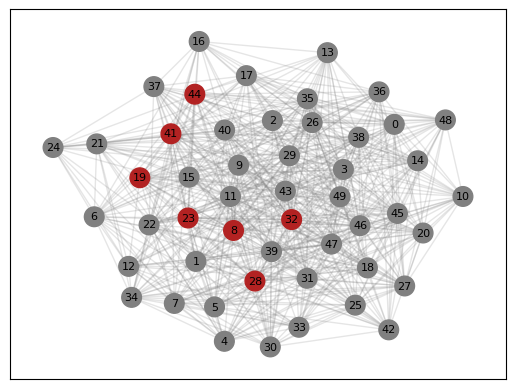

In [6]:
plot_clique(graph, sol.problem, seed=42)